# Taller de Segmentación Semántica con DeepLabV3
Este notebook aplica segmentación semántica a una imagen usando el modelo **DeepLabV3** preentrenado de **torchvision**.


## Paso 1: Instalación de librerías

In [1]:
!pip install torch torchvision matplotlib Pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\JUAN PABLO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Paso 2: Importar librerías necesarias

In [1]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

## Paso 3: Cargar el modelo DeepLabV3
Este modelo ya viene preentrenado en la librería **torchvision**:

In [ ]:
model = models.segmentation.deeplabv3_resnet101(pretrained=True).eval()

## Paso 4: Cargar y preprocesar la imagen
Imagen en la carpeta `imagenes_entrada/`:

In [6]:
input_image = Image.open("../imagenes_entrada/urus.jpg")
preprocess = transforms.Compose([
    transforms.Resize(520),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(input_image).unsqueeze(0)

## Paso 5: Aplicar la segmentación

In [7]:
with torch.no_grad():
    output = model(input_tensor)['out']
output_predictions = output.argmax(1).squeeze().cpu().numpy()

## Paso 6: Visualizar y guardar la máscara segmentada

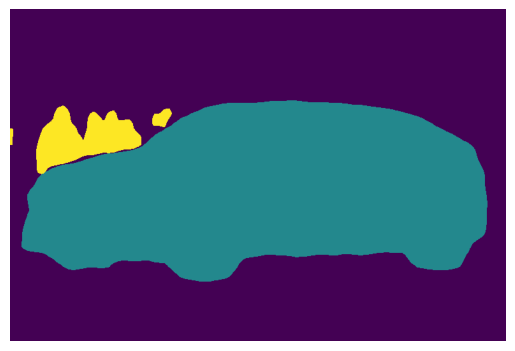

In [8]:
plt.imshow(output_predictions)
plt.axis('off')
plt.savefig("../mascaras_salida/deeplab_output.png")
plt.show()